# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt


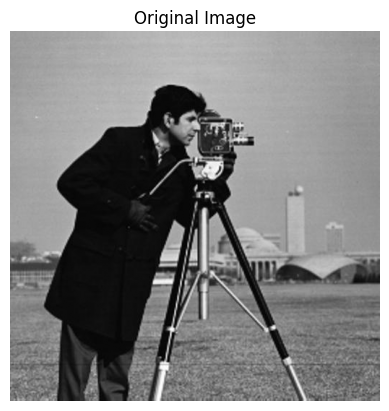

Original size: (512, 512)


In [2]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.jpg")

plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

print("Original size:", img.size)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size
print("Width:", width)
print("Height:", height)
# scaling factors
cx = 2
cy = 2




Width: 512
Height: 512


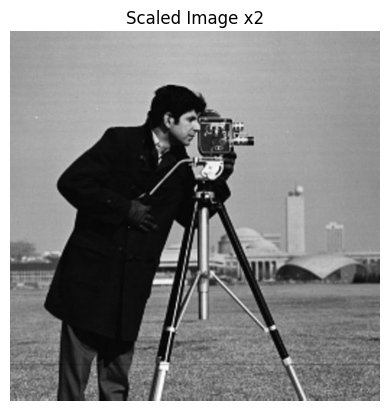

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────
scaled_img = img.resize((width * cx, height * cy), Image.Resampling.LANCZOS)

plt.imshow(scaled_img, cmap="gray")
plt.title("Scaled Image x2")
plt.axis("off")
plt.show()






In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
non_uniform_img = img.resize((width * 2, height), Image.Resampling.LANCZOS)



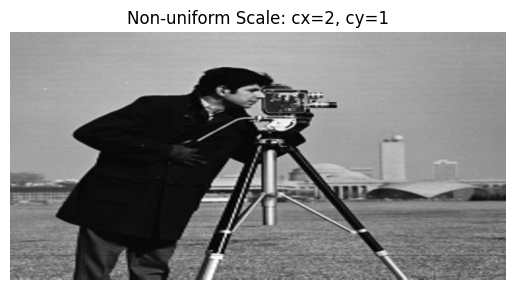

In [7]:
plt.imshow(non_uniform_img, cmap="gray")
plt.title("Non-uniform Scale: cx=2, cy=1")
plt.axis("off")
plt.show()



In [8]:
non_uniform_img.save("task1_1_non_uniform.jpg")
print("Non-uniform size:", non_uniform_img.size)

Non-uniform size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

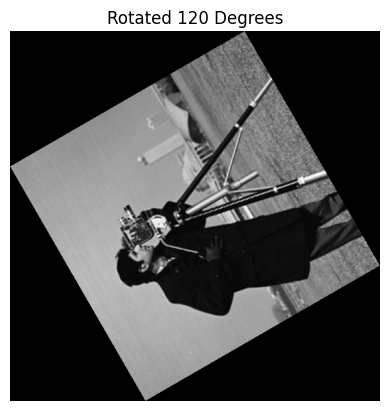

Original size: (512, 512)
Rotated size: (700, 700)


In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
rotated_img = img.rotate(120, expand=True)

plt.imshow(rotated_img, cmap="gray")
plt.title("Rotated 120 Degrees")
plt.axis("off")
plt.show()
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("Width:", width)
print("Height:", height)


Width: 512
Height: 512


In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5
new_width = int(width + shear_factor * height)

print("New width:", new_width)
print("Height:", height)

New width: 768
Height: 512


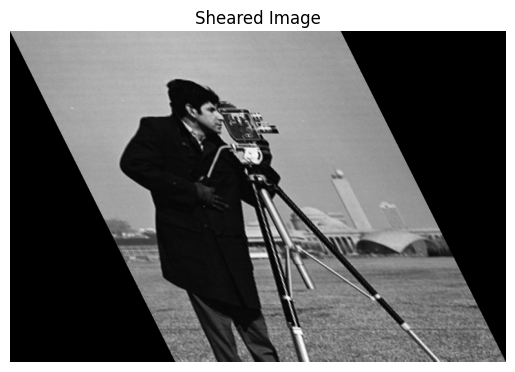

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_img = img.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    (1, -shear_factor, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC
)

plt.imshow(sheared_img, cmap="gray")
plt.title("Sheared Image")
plt.axis("off")
plt.show()

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)

Original size: (512, 512)
Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

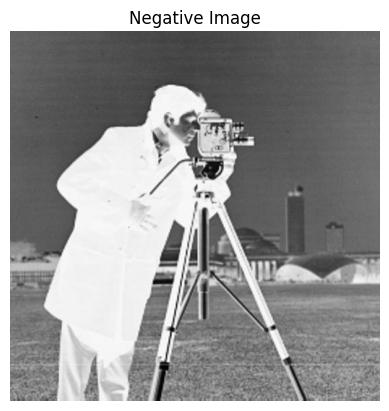

In [14]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
img_array = np.array(img)

negative_arr = 255 - img_array
negative_img = Image.fromarray(negative_arr)

plt.imshow(negative_img, cmap="gray")
plt.title("Negative Image")
plt.axis("off")
plt.show()

negative_img.save("task2_1_negative.jpg")

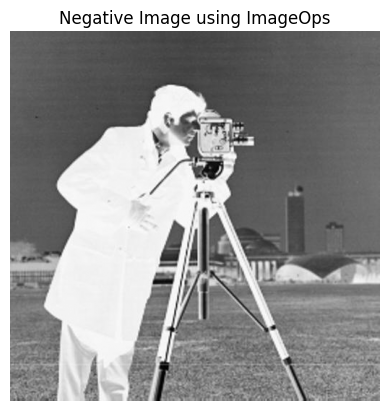

In [15]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(img.convert("L"))

plt.imshow(negative_img2, cmap="gray")
plt.title("Negative Image using ImageOps")
plt.axis("off")
plt.show()

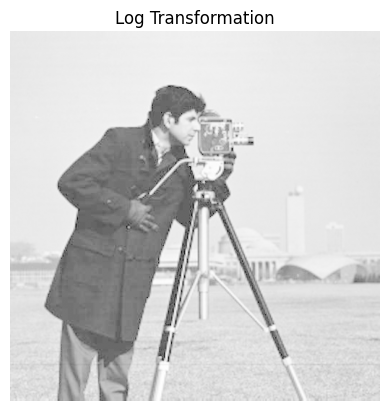

In [16]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

# Apply the log transformation to each pixel
img_array = np.array(img.convert("L")).astype(np.float32)

c = 255 / np.log(1 + np.max(img_array))
log_transformed = c * np.log(1 + img_array)

log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)
log_img = Image.fromarray(log_transformed)

plt.imshow(log_img, cmap="gray")
plt.title("Log Transformation")
plt.axis("off")
plt.show()

log_img.save("task2_2_log.jpg")

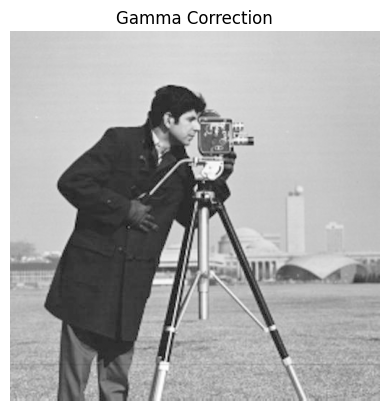

In [17]:

# ── 3. Power-law / Gamma correction ───────────────
img_array = np.array(img.convert("L")).astype(np.float32) / 255.0

gamma = 0.5
gamma_corrected = np.power(img_array, gamma)

gamma_corrected = np.uint8(gamma_corrected * 255)
gamma_img = Image.fromarray(gamma_corrected)

plt.imshow(gamma_img, cmap="gray")
plt.title("Gamma Correction")
plt.axis("off")
plt.show()

gamma_img.save("task2_3_gamma.jpg")
